Author's Name - Kalahe Wattage Sithumi Sandeera Author's UoW - w2052090 Author's IIT No - 20220780

Name of the person who reviewed this Notebook = Thanuri Nikeshala Dodampe

Code Reuse Session 3 - code block 1

In [65]:
# Import pandas for data manipulation
import pandas as pd

Code Reuse Session 3 - code block 2

In [66]:
# Load the dataset into a DataFrame
df_classification = pd.read_csv("/content/Classification_Dataset (2).csv")

Code Reuse Session 3 - code block 3

In [67]:
# Display the first 5 rows of the dataset
df_classification.head()

,Month_of_Birth,Age,Sex,T_Stage,N_Stage,6th_Stage,Differentiated,Grade,A_Stage,Tumor_Size,Estrogen_Status,Progesterone_Status,Regional_Node_Examined,Reginol_Node_Positive,Mortality_Status,N_Stagee
0,12,68.0,1,0,0,0,1,3,1,4.0,1,1,24.0,1,1,0
1,12,50.0,1,1,1,2,0,2,1,35.0,1,1,14.0,5,1,1
2,11,58.0,1,2,2,4,0,2,1,63.0,1,1,14.0,7,1,2
3,3,58.0,1,0,0,0,1,3,1,18.0,1,1,2.0,1,1,0
4,1,47.0,1,1,0,1,1,3,1,41.0,1,1,3.0,1,1,0


Code Reuse Session 3 - code block 4

In [68]:
# Show summary info about the dataset
df_classification.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3997 entries, 0 to 3996
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Month_of_Birth          3997 non-null   int64  
 1   Age                     3997 non-null   float64
 2   Sex                     3997 non-null   int64  
 3   T_Stage                 3997 non-null   int64  
 4   N_Stage                 3997 non-null   int64  
 5   6th_Stage               3997 non-null   int64  
 6   Differentiated          3997 non-null   int64  
 7   Grade                   3997 non-null   int64  
 8   A_Stage                 3997 non-null   int64  
 9   Tumor_Size              3997 non-null   float64
 10  Estrogen_Status         3997 non-null   int64  
 11  Progesterone_Status     3997 non-null   int64  
 12  Regional_Node_Examined  3997 non-null   float64
 13  Reginol_Node_Positive   3997 non-null   int64  
 14  Mortality_Status        3997 non-null   

Code Reuse Session 3 - code block 5

In [69]:
# Drop target column to create feature set
X = df_classification.drop("Mortality_Status", axis=1)
# Extract target column
y = df_classification["Mortality_Status"]

Code Reuse Session 3 - code block 6

In [70]:
# Import function to split data
from sklearn.model_selection import train_test_split

Code Reuse Session 3 - code block 7

In [71]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Code Reuse Session 2 - code block 8

In [72]:
# Import Gaussian Naive Bayes
from sklearn.naive_bayes import GaussianNB
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression
# import knn
from sklearn.neighbors import KNeighborsClassifier

Tutorial 2 - code block 9

In [73]:
# Create Gaussian Naive Bayes model
nb_clf = GaussianNB()
# Create Logistic Regression model
lr_clf = LogisticRegression(random_state=42)
# Create KNN model with k=5
knn_clf = KNeighborsClassifier(n_neighbors=5)

Code Reuse Session 2 - code block 10

In [74]:
# Train Naive Bayes model
nb_clf.fit(X_train, y_train)
# Train Logistic Regression model
lr_clf.fit(X_train, y_train)
# Train KNN model
knn_clf.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


KNeighborsClassifier()

Code Reuse Session 2 - code block 11

In [75]:
# Predict with Naive Bayes model
nb_y_pred = nb_clf.predict(X_test)
# Predict with Logistic Regression model
lr_y_pred = lr_clf.predict(X_test)
# Predict with KNN model
knn_y_pred = knn_clf.predict(X_test)

Code Reuse Session 3 - code block 12

In [76]:
# Import VotingClassifier for ensemble learning
from sklearn.ensemble import VotingClassifier

Code Reuse Session 3 - code block 13

In [77]:
# Define the ensemble classifier with Naive Bayes, Logistic Regression, and KNN
estimators = [('NB', nb_clf), ('LR', lr_clf), ('KNN', knn_clf)]
# Create the Voting Classifier using soft voting
ensemble_clf = VotingClassifier(estimators=estimators, voting='soft')

Code Reuse Session 3 - code block 14

In [78]:
# Train the ensemble classifier on the training data
ensemble_clf.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


VotingClassifier(estimators=[('NB', GaussianNB()),
                             ('LR', LogisticRegression(random_state=42)),
                             ('KNN', KNeighborsClassifier())],
                 voting='soft')

Code Reuse Session 3 - code block 15

In [79]:
# Make predictions using the trained ensemble classifier on the test data
ensemble_y_pred = ensemble_clf.predict(X_test)

Code Reuse Session 2 - code block 16

In [80]:
# Import accuracy_score to evaluate model accuracy
from sklearn.metrics import accuracy_score
# Import classification_report to generate detailed classification metrics
from sklearn.metrics import classification_report
# Import roc_auc_score to compute the AUC score for the ROC curve
from sklearn.metrics import roc_auc_score
# Import roc_curve to generate the ROC curve data points
from sklearn.metrics import roc_curve
# Import confusion_matrix to compute the confusion matrix for the model
from sklearn.metrics import confusion_matrix

Code Reuse Session 2 - code block 17

In [81]:
# Print accuracy for Naive Bayes model
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_y_pred))
# Print accuracy for Logistic Regression model
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_y_pred))
# Print accuracy for KNN model
print("KNN Accuracy:", accuracy_score(y_test, knn_y_pred))
# Print accuracy for Ensemble model
print("Ensemble Accuracy:", accuracy_score(y_test, ensemble_y_pred))

Naive Bayes Accuracy: 0.76875
Logistic Regression Accuracy: 0.8525
KNN Accuracy: 0.83375
Ensemble Accuracy: 0.82125


Code Reuse Session 2 - code block 18

In [82]:
# Print classification report for Naive Bayes model
print("Naive Bayes Classification Report:\n", classification_report(y_test, nb_y_pred))
# Print classification report for Logistic Regression model
print("Logistic Regression Classification Report:\n", classification_report(y_test, lr_y_pred))
# Print classification report for KNN model
print("KNN Classification Report:\n", classification_report(y_test, knn_y_pred))
# Print classification report for Ensemble model
print("Ensemble Classification Report:\n", classification_report(y_test, ensemble_y_pred))

Naive Bayes Classification Report:
               precision    recall  f1-score   support

           1       0.88      0.84      0.86       677
           2       0.30      0.37      0.33       123

    accuracy                           0.77       800
   macro avg       0.59      0.61      0.60       800
weighted avg       0.79      0.77      0.78       800

Logistic Regression Classification Report:
               precision    recall  f1-score   support

           1       0.86      0.98      0.92       677
           2       0.58      0.15      0.23       123

    accuracy                           0.85       800
   macro avg       0.72      0.56      0.58       800
weighted avg       0.82      0.85      0.81       800

KNN Classification Report:
               precision    recall  f1-score   support

           1       0.86      0.96      0.91       677
           2       0.39      0.14      0.20       123

    accuracy                           0.83       800
   macro avg       0

Code Reuse Session 2 - code block 19

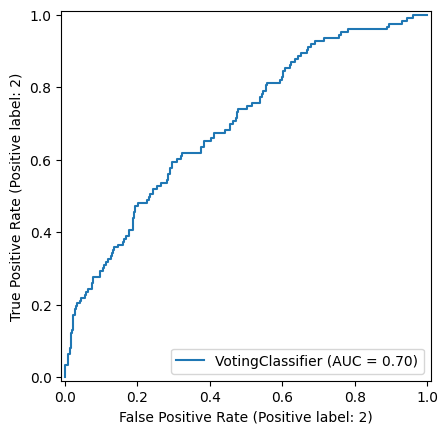

In [83]:
# Import ROC curve display
from sklearn.metrics import RocCurveDisplay

# Display the ROC curve for ensemble model
RocCurveDisplay.from_estimator(ensemble_clf, X_test, y_test)

Code Reuse Session 2 - code block 20

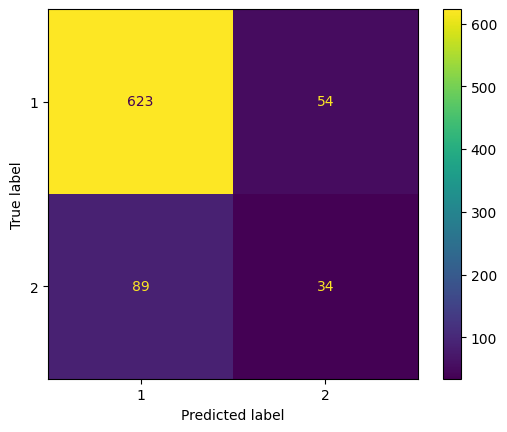

In [84]:
from sklearn.metrics import ConfusionMatrixDisplay

# Create confusion matrix for ensemble model
ensemble_cm = confusion_matrix(y_test, ensemble_y_pred, labels=ensemble_clf.classes_)

# Display the confusion matrix
ConfusionMatrixDisplay(confusion_matrix=ensemble_cm, display_labels=ensemble_clf.classes_).plot()

Code Reuse Session 3 - code block 21

In [43]:
# Load regression data from CSV
df_regression = pd.read_csv("/content/Regression_Dataset (2).csv")

Code Reuse Session 3 - code block 22

In [44]:
# Show summary info
df_regression.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 613 entries, 0 to 612
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Month_of_Birth          613 non-null    int64  
 1   Age                     613 non-null    float64
 2   Sex                     613 non-null    int64  
 3   T_Stage                 613 non-null    int64  
 4   N_Stage                 613 non-null    int64  
 5   6th_Stage               613 non-null    int64  
 6   Differentiated          613 non-null    int64  
 7   Grade                   613 non-null    int64  
 8   A_Stage                 613 non-null    int64  
 9   Tumor_Size              613 non-null    float64
 10  Estrogen_Status         613 non-null    int64  
 11  Progesterone_Status     613 non-null    int64  
 12  Regional_Node_Examined  613 non-null    float64
 13  Reginol_Node_Positive   613 non-null    int64  
 14  Survival_Months         613 non-null    in

Code Reuse Session 3 - code block 23

In [45]:
 # Display the first first few rows of the regression dataset
df_regression.head(10)

,Month_of_Birth,Age,Sex,T_Stage,N_Stage,6th_Stage,Differentiated,Grade,A_Stage,Tumor_Size,Estrogen_Status,Progesterone_Status,Regional_Node_Examined,Reginol_Node_Positive,Survival_Months
0,4,40.0,1,1,0,1,0,2,1,30.0,1,1,9.0,1,14
1,8,68.0,1,0,0,0,0,2,1,13.0,1,1,9.0,1,64
2,10,57.0,1,2,2,4,0,2,1,70.0,1,1,12.0,12,42
3,11,42.0,1,0,2,4,0,2,1,9.0,0,0,15.0,2,39
4,1,67.0,1,0,0,0,0,2,1,13.0,1,1,16.0,3,60
5,8,31.0,1,2,2,4,1,3,1,70.0,1,1,23.0,23,44
6,3,64.0,1,1,2,4,1,3,1,34.0,1,0,24.0,20,12
7,8,53.0,1,2,0,2,1,3,1,60.0,1,1,8.0,1,91
8,1,63.0,1,1,1,2,3,1,1,26.0,1,1,5.0,4,87
9,12,45.0,1,1,2,4,1,3,1,25.0,1,1,21.0,16,40


Code Reuse Session 3 - code block 24

In [46]:
# Drop the target column to create feature set for regression
X_reg = df_regression.drop("Survival_Months", axis=1)

# Select the target column for regression
y_reg = df_regression["Survival_Months"]

Code Reuse Session 3 - code block 25

In [47]:
# Split regression data into train and test sets
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

Code Reuse Session 3 - code block 26

In [48]:
# Import Decision Tree Regressor for regression task
from sklearn.tree import DecisionTreeRegressor

Code Reuse Session 3 - code block 27

In [49]:
# Initialize a Decision Tree Regressor model
dt_reg1 = DecisionTreeRegressor()

Code Reuse Session 3 - code block 28

In [50]:
# Train the Decision Tree Regressor on the training data
dt_reg1.fit(X_train_reg, y_train_reg)

DecisionTreeRegressor()

Code Reuse Session 3 - code block 29

In [51]:
# Make predictions on the test set
dt_reg1_y_pred = dt_reg1.predict(X_test_reg)

Code Reuse Session 3 - code block 30

In [52]:
# Import sklearn metrics module
from sklearn import metrics

Code Reuse Session 3 - code block 31

In [53]:
# Calculate and print the Mean Squared Error (MSE)
print("DT-1 MSE:", metrics.mean_squared_error(y_test_reg, dt_reg1_y_pred))

# Calculate and print the Mean Absolute Error (MAE)
print("DT-1 MAE:", metrics.mean_absolute_error(y_test_reg, dt_reg1_y_pred))

# Calculate and print the R² score
print("DT-1 R2:", metrics.r2_score(y_test_reg, dt_reg1_y_pred))

DT-1 MSE: 1259.8455284552845
DT-1 MAE: 27.16260162601626
DT-1 R2: -0.8445656442565621


Code Reuse Session 3 - code block 32

In [54]:
# Create a Decision Tree Regressor with pruning
dt_reg2 = DecisionTreeRegressor(max_depth=3)

Code Reuse Session 3 - code block 33

In [55]:
# Train the pruned Decision Tree Regressor on the training data
dt_reg2.fit(X_train_reg, y_train_reg)
# Make predictions on the test set
dt_reg2_y_pred = dt_reg2.predict(X_test_reg)

Code Reuse Session 3 - code block 34

In [56]:
# Calculate and print the Mean Squared Error for DT-2
print("DT-2 MSE:", metrics.mean_squared_error(y_test_reg, dt_reg2_y_pred))
# Calculate and print the Mean Absolute Error for DT-2
print("DT-2 MAE:", metrics.mean_absolute_error(y_test_reg, dt_reg2_y_pred))
# Calculate and print the R-squared score for DT-2
print("DT-2 R2:", metrics.r2_score(y_test_reg, dt_reg2_y_pred))

DT-2 MSE: 703.1542608039063
DT-2 MAE: 21.741043520314793
DT-2 R2: -0.029502556302908323


Code Reuse Session 3 - code block 35

In [62]:
# import for sklearn tree module
from sklearn.tree import plot_tree

# import for matplotlib pyplot as plt
from matplotlib import pyplot as plt

Code Reuse Session 3 - code block 36

In [58]:
# Create a figure to plot the decision tree
Tree_figure = plt.figure(figsize=(20, 20))

<Figure size 2000x2000 with 0 Axes>

Code Reuse Session 3 - code block 37

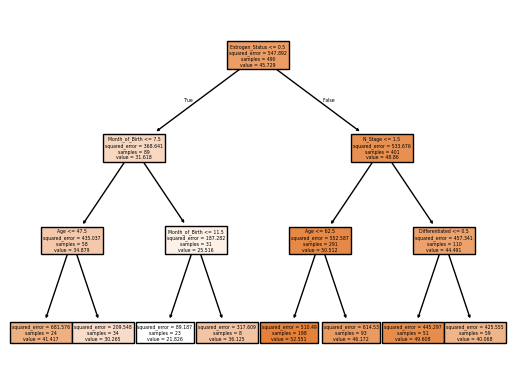

In [63]:
DT_graph = plot_tree(dt_reg2, feature_names=X_reg.columns, filled=True)

Code Reuse Session 3 - code block 38

In [64]:
Tree_figure.savefig("DT_graph.png")